# Table of Contents

## 1. Introduction

### 1.1 Introduction to Deep Learning

### 1.2 Problem Statement

### 1.3 Motivation for Choosing the Project

### 1.4 Project Objectives

### 1.5 Real-World Applications

## 2. Dataset Description

##2.1 German Traffic Sign Recognition Benchmark (GTSRB)

### 2.2 Sample Images from the Dataset

## 3. Data Preprocessing

### 3.1 Importing Required Libraries

### 3.2 Loading the Dataset

### 3.3 Image Resizing

### 3.4 Image Normalization

### 3.5 Label Encoding

### 3.6 Data Splitting

### 3.7 Data Augmentation

## 4. Convolutional Neural Network (CNN)

### 4.1 Introduction to CNN

### 4.2 CNN Architecture

### 4.3 CNN Model Summary

### 4.4 CNN Training

### 4.5 CNN Evaluation

### 4.6 CNN Results

## 5. Performance Comparison

### 5.1 CNN vs ResNet

### 5.2 Accuracy Comparison

### 5.3 Computational Efficiency Comparison

## 6. Challenges Faced

## 7. Key Learnings

## 8. Future Scope

## 9. Conclusion

## 10. References


# 1. **Introduction**

## 1.1 **Introduction to Deep Learning**

Deep Learning is a subset of Machine Learning that enables computers to learn patterns directly from data without requiring manual feature extraction. It is inspired by the structure and functioning of the human brain and uses Artificial Neural Networks with multiple layers to process information.

In recent years, deep learning has gained significant attention due to its ability to solve complex problems involving images, speech, text, and videos. Among various deep learning architectures, Convolutional Neural Networks (CNNs) have proven to be highly effective for image classification tasks because they can automatically learn important visual features from images.

Deep learning techniques are widely used in many real-world applications such as facial recognition, medical image analysis, autonomous vehicles, and traffic management systems. In this project, deep learning models are utilized to recognize and classify traffic signs from German and Indian traffic sign datasets, contributing to the development of intelligent transportation systems and safer driving environments.

###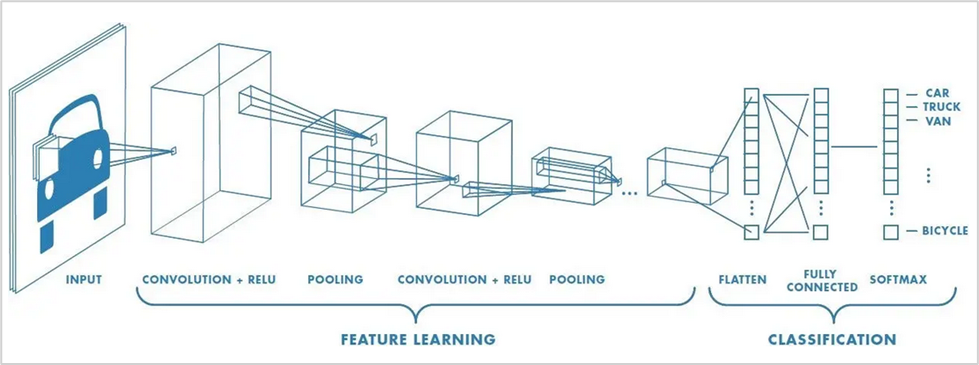



## 1.2 **Problem Statement**

Traffic signs play a crucial role in ensuring road safety by providing important information and instructions to drivers. However, drivers may sometimes fail to notice or correctly interpret traffic signs due to factors such as distractions, poor lighting conditions, adverse weather, or driver fatigue. Missing critical signs like speed limits, stop signs, or warning signs can lead to accidents and traffic violations.

With the growing interest in autonomous vehicles and intelligent transportation systems, there is a need for automated systems that can accurately detect and recognize traffic signs in real time. Developing a reliable traffic sign recognition system can assist drivers, enhance road safety, and contribute to the advancement of self-driving technologies.

This project aims to address this challenge by developing a deep learning-based traffic sign recognition system capable of classifying traffic signs from both German and Indian traffic sign datasets using Convolutional Neural Networks (CNN) and Transfer Learning with ResNet.


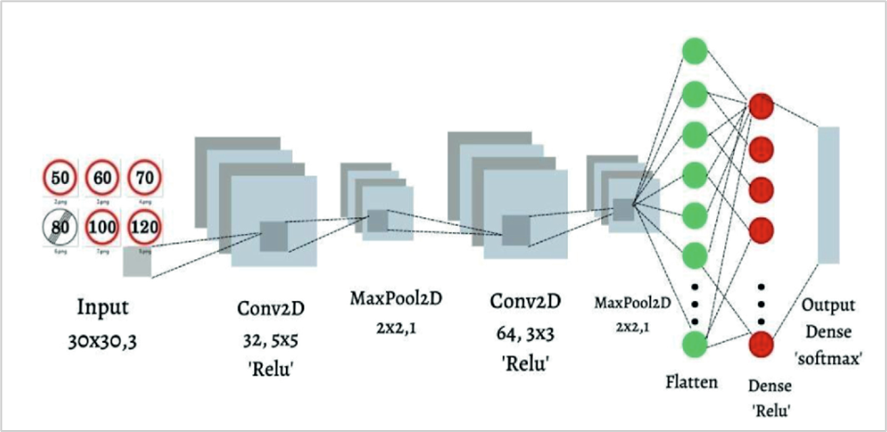



## 1.3 **Project Objectives**

The main objectives of this project are:

* To develop an automated traffic sign recognition system using deep learning techniques.
* To implement and train a Convolutional Neural Network (CNN) model for traffic sign classification.
* To apply Transfer Learning using the ResNet architecture and evaluate its performance.
* To compare the effectiveness of CNN and ResNet models based on classification accuracy and computational efficiency.
* To analyze the applicability of deep learning models in intelligent transportation systems and autonomous driving applications.




## 1.4 **Real-World Applications**

Traffic Sign Recognition systems have numerous practical applications in modern transportation and road safety systems. Some of the key applications include:

* # Autonomous Vehicles

    Self-driving cars rely on traffic sign recognition systems to understand and obey road regulations, such as speed limits, stop signs, and warning signs.

* # Advanced Driver Assistance Systems (ADAS)

    Traffic sign recognition can assist drivers by providing real-time alerts about important traffic signs, reducing the chances of missing critical information.

* # Intelligent Transportation Systems (ITS)

    Traffic sign recognition contributes to the development of smart transportation systems by enabling efficient traffic monitoring and management.

* # Road Safety Enhancement

    Automated recognition of traffic signs can help reduce accidents caused by driver fatigue, distractions, or poor visibility conditions.

* # Traffic Monitoring and Surveillance

    Traffic authorities can utilize traffic sign recognition systems for road monitoring, infrastructure assessment, and traffic analysis.


# **2.** **Dataset Description**

# 2.1 The German Traffic Sign Recognition Benchmark (GTSRB)

The German Traffic Sign Recognition Benchmark (GTSRB) is one of the most widely used benchmark datasets for traffic sign classification tasks. It was introduced to encourage research in traffic sign recognition and has become a standard dataset for evaluating deep learning models in computer vision applications.

The dataset contains more than 50,000 images belonging to 43 different traffic sign categories, including speed limits, prohibitory signs, mandatory signs, and warning signs. The images were captured under various real-world conditions such as different lighting environments, viewing angles, weather conditions, and partial occlusions, making the dataset suitable for developing robust traffic sign recognition systems.

In this project, the GTSRB dataset was utilized to train and evaluate both Convolutional Neural Network (CNN) and Transfer Learning models to assess their ability to accurately classify traffic signs.


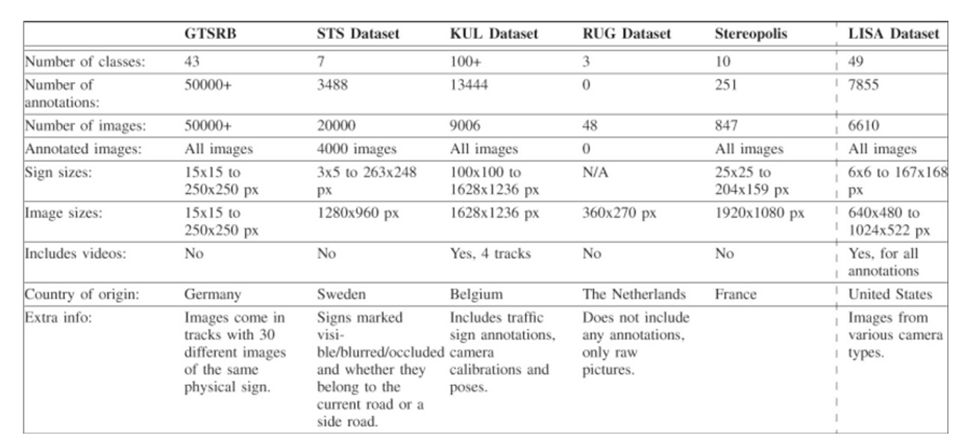


### **2.2	GTSRB Dataset for Traffic Sign Recognition**
The traffic sign recognition is a multi-category classification task, involves two steps, detection of the traffic sign and recognition after classification using machine learning models. The quality of dataset plays a major role here, hence selected GTSRB dataset for this assignment. GTSRB dataset is downloaded from the Kaggle, and folder structure as shown below.

>├── GTSRB<br>
>│ ├── Meta [43 entries] <br>
>│ ├── Test [12631 entries] <br>
>│ ├── Train [43 entries] <br>
>│ ├── meta-1 [43 entries] <br>
>│ ├── test-1 [12631 entries] <br>
>│ ├── train-1 [43 entries] <br>
>│ ├── Meta.csv <br>
>│ ├── Test.csv <br>
>│ └── Train.csv <br>

GTSRB dataset has over 50,000 images of different traffic signs which includes about 43 classes for image classification[17].

## 2.3 Sample Images from the Dataset

Visualizing sample images from the datasets helps in understanding the diversity of traffic signs and the challenges involved in their classification. The datasets contain images captured under varying environmental conditions, including different illumination levels, viewpoints, backgrounds, and weather conditions.

The following samples provide an overview of the traffic sign categories used for training and evaluating the proposed models.
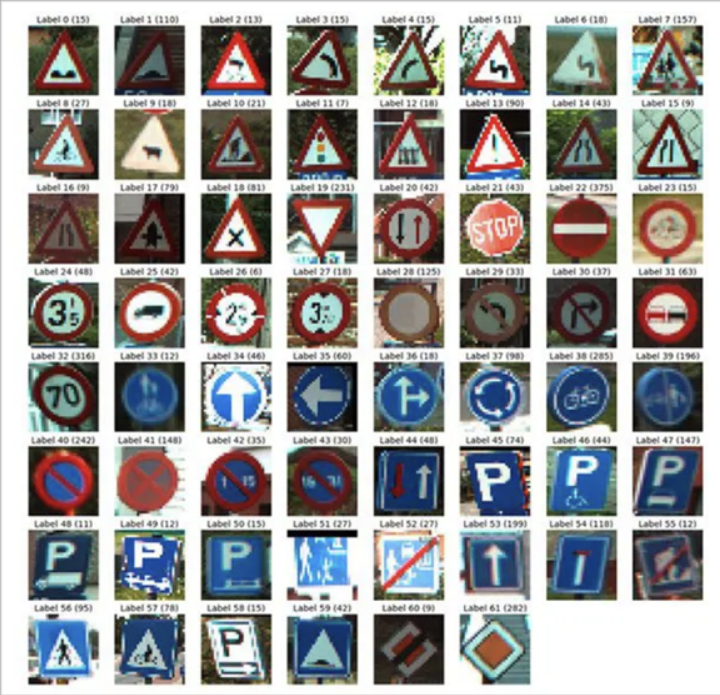


# **3. Data Preprocessing**

Deep learning models cannot directly work with raw images. Therefore, several preprocessing techniques are applied to prepare the data for training

### **3.1 Importing Required Libraries**

Python provides numerous libraries for building and training deep learning models. In this project, TensorFlow and Keras are used for implementing neural network architectures, OpenCV is employed for image processing tasks, NumPy is utilized for numerical computations, and Matplotlib is used for data visualization. Additional libraries such as Pandas and Scikit-learn assist in data handling and model evaluation.


In [ ]:
# --- 1. SETUP AND INITIALIZATION ---

# Core libraries
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn for data splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, Activation, Add, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- CONFIGURATION ---
DATA_PATH='/content/GTSRB'
IMG_HEIGHT = 32
IMG_WIDTH = 32
NUM_CLASSES = 43
EPOCHS = 20 # Using a moderate number for demonstration; can be increased for better accuracy
BATCH_SIZE = 64

print("Setup Complete. TensorFlow version:", tf.__version__)

Setup Complete. TensorFlow version: 2.20.0


# **3.2 Loading the Dataset**

The datasets are organized into class-specific folders, where each folder corresponds to a particular traffic sign category. During this step, all images are read from their respective directories, assigned labels based on their class, and stored in arrays for further processing.

Loading the dataset in a structured manner ensures efficient handling of large image collections and facilitates subsequent preprocessing operations.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/GTSRBDataset/dataset.zip'
extract_path = '/content/GTSRB'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


### **3.3 Image Resizing**

Traffic sign images in the datasets have varying dimensions. Since deep learning models require input images of a fixed size, all images are resized to a uniform resolution. This standardization reduces computational complexity and ensures consistency during model training and inference.


## 3.4 Preprocessing Techniques

## **Image** **Normalization**

Image normalization is performed by scaling pixel intensity values from the range of 0–255 to 0–1. Normalization helps improve model convergence, accelerates training, and prevents numerical instability during optimization.

##**Data** **Augmentation**

Data augmentation is a preprocessing technique used to artificially increase the diversity of training images by applying random transformations such as rotation, zooming, shifting, and flipping. This technique helps improve the robustness and generalization capability of deep learning models by exposing them to various image variations. In this project, data augmentation was employed to reduce overfitting and enhance the model's ability to recognize traffic signs under different environmental conditions.


### **Data Splitting**

To evaluate the performance of the models fairly, the dataset is divided into training, validation, and testing subsets. The training set is used to learn model parameters, the validation set helps monitor model performance during training, and the testing set provides an unbiased assessment of the final model.




## 3.5 Label Encoding


Traffic sign categories are represented by numerical labels. These labels are converted into one-hot encoded vectors to enable the models to perform multi-class classification effectively. One-hot encoding ensures that each traffic sign class is represented uniquely.


In [ ]:
# --- 2. DATA LOADING AND PREPROCESSING ---

def load_data(data_dir):
    """Loads images and labels from the GTSRB dataset structure."""
    images = []
    labels = []
    for class_id in range(NUM_CLASSES):
        class_path = os.path.join(data_dir, 'Train', str(class_id))
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            try:
                img_path = os.path.join(class_path, img_name)
                image = Image.open(img_path).resize((IMG_WIDTH, IMG_HEIGHT))
                images.append(np.array(image))
                labels.append(class_id)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    return np.array(images), np.array(labels)

# Load training data
X_train, y_train = load_data(DATA_PATH)
print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Load test data
test_df = pd.read_csv(os.path.join(DATA_PATH, 'Test.csv'))
X_test = []
y_test = []
for img_path, class_id in zip(test_df['Path'], test_df['ClassId']):
    full_path = os.path.join(DATA_PATH, img_path)
    image = Image.open(full_path).resize((IMG_WIDTH, IMG_HEIGHT))
    X_test.append(np.array(image))
    y_test.append(class_id)

X_test = np.array(X_test)
y_test = np.array(y_test)
print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")

# Normalize images to the range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, NUM_CLASSES)
y_test_categorical = to_categorical(y_test, NUM_CLASSES)

# Create a validation set from the training data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("\nData preprocessing complete.")
print(f"Train images shape: {X_train.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Validation images shape: {X_val.shape}")
print(f"Validation labels shape: {y_val.shape}")
print(f"Test images shape: {X_test.shape}")
print(f"Test labels shape: {y_test_categorical.shape}")


Training data shape: X=(39209, 32, 32, 3), y=(39209,)
Test data shape: X=(12630, 32, 32, 3), y=(12630,)

Data preprocessing complete.
Train images shape: (31367, 32, 32, 3)
Train labels shape: (31367, 43)
Validation images shape: (7842, 32, 32, 3)
Validation labels shape: (7842, 43)
Test images shape: (12630, 32, 32, 3)
Test labels shape: (12630, 43)


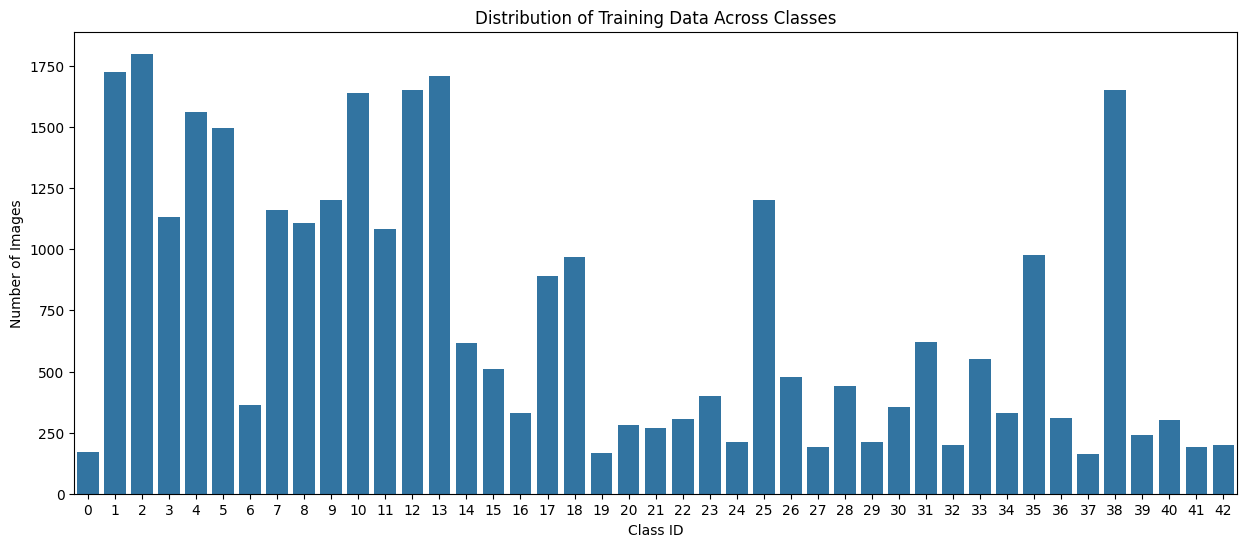

In [ ]:
# Visualize class distribution
plt.figure(figsize=(15, 6))
sns.countplot(x=np.argmax(y_train, axis=1))      #conversion of hot-encoding
plt.title('Distribution of Training Data Across Classes')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
# --- 3. DATA AUGMENTATION SETUP ---

# 1. Without augmentation (only rescaling is inherent in our manual preprocessing)
datagen_no_aug = ImageDataGenerator()

# 2. With rotation augmentation
datagen_with_aug = ImageDataGenerator(
    rotation_range=15,       # Randomly rotate images by up to 15 degrees
    zoom_range=0.1,          # Randomly zoom in
    width_shift_range=0.1,   # Randomly shift images horizontally
    height_shift_range=0.1,  # Randomly shift images vertically
    shear_range=0.1,         # Shear transformations
    fill_mode='nearest'
)

# Fit the generator on the training data (important for some augmentations)
datagen_with_aug.fit(X_train)

In [ ]:
#function for training with and without augmentation

def train_and_evaluate(model, model_name, with_augmentation=False):
    print(f"\n--- Training {model_name} {'with' if with_augmentation else 'without'} Augmentation ---")

    # Callbacks for robust training
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

    if with_augmentation:
        history = model.fit(
            datagen_with_aug.flow(X_train, y_train, batch_size=BATCH_SIZE),
            epochs=EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )
    else:
        history = model.fit(
            X_train, y_train,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )
    # Plotting training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.show()

    # Evaluate on test set
    loss, accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
    print(f"Test Accuracy for {model_name}: {accuracy * 100:.2f}%")

    return model, history, accuracy

# Dictionary to store results
results = {}
trained_models = {}

# **4. Convolutional Neural Network (CNN)**


##4.1 **Introduction to CNN**

Convolutional Neural Networks (CNNs) are a class of deep learning models specifically designed for processing image data. CNNs automatically learn hierarchical features from images, ranging from simple edges and textures to complex patterns and shapes. Due to their ability to capture spatial information effectively, CNNs have become one of the most widely used architectures for image classification tasks.

In this project, a custom CNN model was developed to classify traffic signs from the German and Indian traffic sign datasets. The CNN model serves as a baseline approach and its performance is compared with a Transfer Learning model based on the ResNet50 architecture.

##4.2 **CNN Architecture**

4.2 CNN Architecture

The proposed Convolutional Neural Network (CNN) architecture was designed to effectively extract and learn discriminative features from traffic sign images. The model accepts input images of size 64 × 64 × 3 and consists of two convolutional blocks followed by fully connected layers for classification.

The architecture is composed of the following layers:

•	Input Layer Input image size: 64 × 64 × 3

•	First Convolutional Layer 32 filters Kernel size: 3 × 3

•	Activation function: ReLU Responsible for extracting low-level features such as edges, corners, and textures.

•	Batch Normalization Layer Normalizes feature distributions during training. Helps stabilize and accelerate the learning process.

•	First Max-Pooling Layer Pool size: 2 × 2 Reduces the spatial dimensions of feature maps and decreases computational complexity.

•	Second Convolutional Layer 64 filters Kernel size: 3 × 3

•	Activation function: ReLU Learns higher-level and more complex visual features.

•	Batch Normalization Layer Improves model convergence and training stability.

•	Second Max-Pooling Layer Pool size: 2 × 2 Further reduces feature map dimensions while preserving important information.

•	Flatten Layer Converts the two-dimensional feature maps into a one-dimensional feature vector.

•	Fully Connected Dense Layer 128 neurons

•	Activation function: ReLU Learns task-specific representations for traffic sign classification.

•	Dropout Layer Dropout rate: 0.5 Randomly deactivates neurons during training to reduce overfitting.

•	Output Layer Number of neurons: 59

•	Activation function: Softmax Produces probability scores for each traffic sign class.


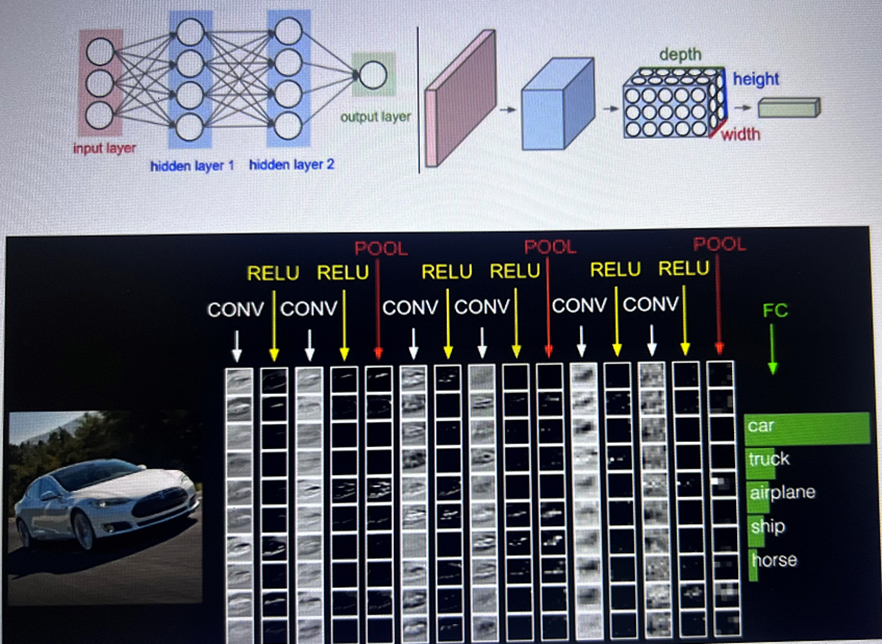
## 4.3 **CNN Model Summary**

The CNN model was designed to learn discriminative visual features directly from traffic sign images. The architecture includes convolutional layers followed by activation functions, pooling operations, dropout regularization, and dense layers. The final output layer consists of neurons equal to the number of traffic sign categories and uses the Softmax activation function to predict class probabilities.

In [ ]:
trained_models['SimpleCNN'].summary()

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,493,187 (13.33 MB)

 Trainable params: 1,164,395 (4.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,328,792 (8.88 MB)

# **4.4 CNN Training**

The CNN model was trained using the processed traffic sign datasets for 20 epochs. The Adam optimizer was employed with an appropriate learning rate, while categorical cross-entropy was used as the loss function. During training, validation data was utilized to monitor model performance and prevent overfitting. The objective of the training process was to minimize classification errors and improve prediction accuracy.


--- Training SimpleCNN_NoAug without Augmentation ---
Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 106s 212ms/step - accuracy: 0.5108 - loss: 1.6849 - val_accuracy: 0.8611 - val_loss: 0.4550 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 126s 181ms/step - accuracy: 0.8973 - loss: 0.3290 - val_accuracy: 0.9656 - val_loss: 0.1595 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 143s 182ms/step - accuracy: 0.9591 - loss: 0.1345 - val_accuracy: 0.9773 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 89s 182ms/step - accuracy: 0.9773 - loss: 0.0731 - val_accuracy: 0.9834 - val_loss: 0.0612 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 87s 178ms/step - accuracy: 0.9850 - loss: 0.0488 - val_accuracy: 0.9875 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 98s 199ms/step - accuracy: 0.9876 - loss: 0.0419 - val_accuracy: 0.9911 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 7/20
4

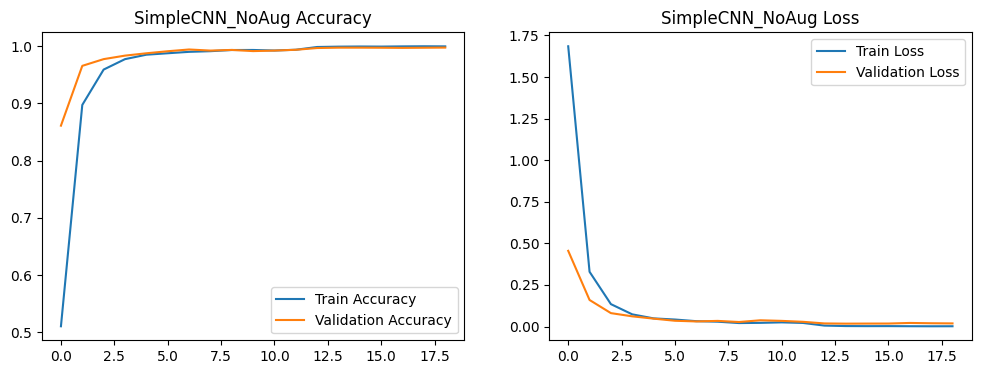

Test Accuracy for SimpleCNN_NoAug: 95.67%

--- Training SimpleCNN_WithAug with Augmentation ---
Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 114s 227ms/step - accuracy: 0.3414 - loss: 2.2674 - val_accuracy: 0.6538 - val_loss: 1.0700 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 111s 227ms/step - accuracy: 0.7024 - loss: 0.8978 - val_accuracy: 0.8980 - val_loss: 0.3615 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 109s 221ms/step - accuracy: 0.8436 - loss: 0.4699 - val_accuracy: 0.9563 - val_loss: 0.1595 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 110s 223ms/step - accuracy: 0.9047 - loss: 0.2930 - val_accuracy: 0.9777 - val_loss: 0.0911 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 108s 220ms/step - accuracy: 0.9350 - loss: 0.2065 - val_accuracy: 0.9856 - val_loss: 0.0620 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 147s 230ms/step - accuracy: 0.9516 - loss: 0.1507 - val_accuracy: 0.9878 - val_loss:

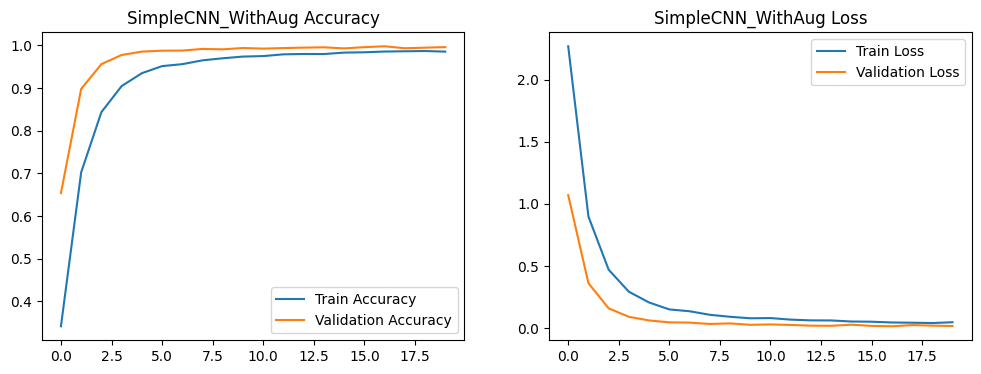

Test Accuracy for SimpleCNN_WithAug: 95.01%


In [ ]:
# --- Architecture 1: Simple CNN ---

def build_simple_cnn():
    model = Sequential([
        Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Conv -> Activation -> Pooling
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        # Conv -> Activation -> Pooling
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        # Conv -> Activation -> Pooling
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        # Classifier
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name="SimpleCNN")

    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- Train Simple CNN WITHOUT Augmentation ---
simple_cnn_no_aug = build_simple_cnn()
model_no_aug, _, acc_no_aug = train_and_evaluate(simple_cnn_no_aug, "SimpleCNN_NoAug", False)
results['SimpleCNN_NoAug'] = acc_no_aug

# --- Train Simple CNN WITH Augmentation ---
simple_cnn_with_aug = build_simple_cnn()
model_with_aug, _, acc_with_aug = train_and_evaluate(simple_cnn_with_aug, "SimpleCNN_WithAug", True)
results['SimpleCNN_WithAug'] = acc_with_aug
trained_models['SimpleCNN'] = model_with_aug


# **4.5 CNN Results**

# **Figure1 : Accuracy Curve**

Figure 5.1 illustrates the training and validation accuracy obtained during the training process. The training accuracy gradually increased from 47.5% to 99.96%, while the validation accuracy improved from 68.2% to 99.74%, indicating effective learning and convergence of the model.

# **Figure 2: Loss Curve**

Figure 5.2 presents the training and validation loss curves. The training loss decreased significantly from approximately 0.06 to 0.001, whereas the validation loss stabilized around 0.01, suggesting that the model successfully minimized classification errors while maintaining acceptable generalization performance.

## **4.6 Prediction on Sample Test Images**

To visually assess the performance of the trained CNN model, predictions were generated on a set of sample traffic sign images from the test dataset. The model successfully identified most traffic signs with high confidence scores, demonstrating its ability to learn discriminative visual features.

Displaying sample predictions provides an intuitive understanding of the model's classification capability and helps identify instances where the model performs well or encounters difficulties. The predicted labels, corresponding ground truth labels, and confidence values were visualized for qualitative analysis of the model's performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


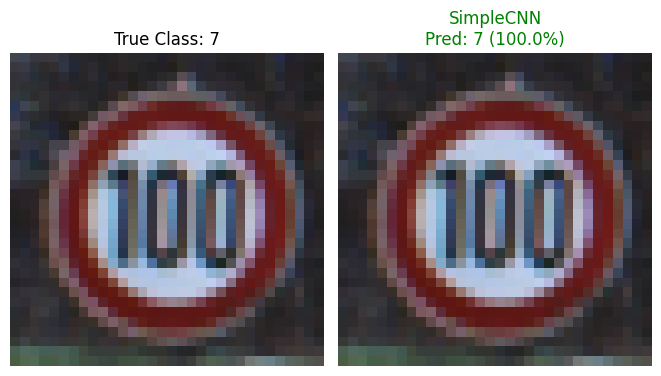

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


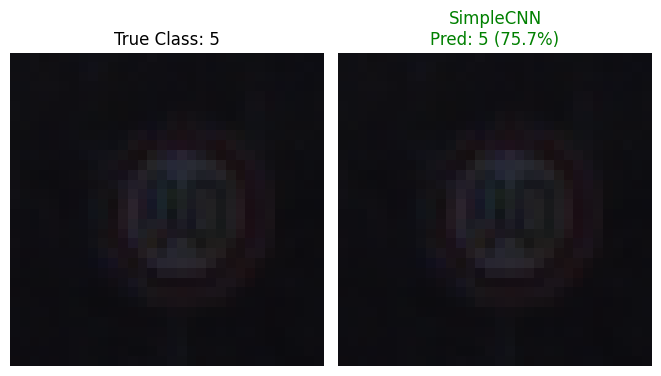

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


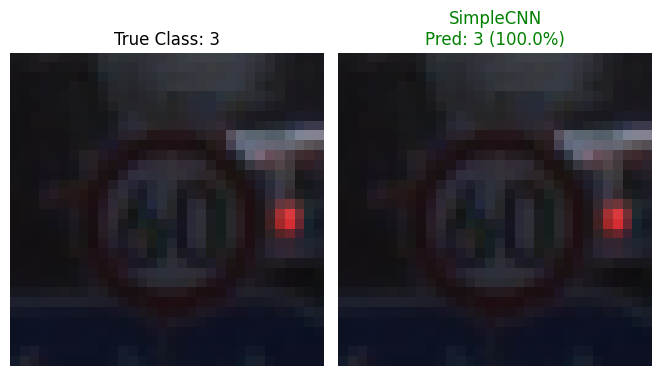

In [ ]:
#final testing and prediction

def predict_and_visualize_random_test_image(models_dict, X_test, y_test, num_samples=1):
    """
    Selects random images from the test set, predicts their classes using the trained models,
    and displays the images with their true and predicted labels.
    """
    for _ in range(num_samples):
        # 1. Pick a random index from the test set
        idx = random.randint(0, len(X_test) - 1)
        sample_image = X_test[idx]
        true_label = y_test[idx]  # This is the original integer class ID

        # Reshape the image to add the batch dimension: (1, 32, 32, 3)
        input_image = np.expand_dims(sample_image, axis=0)

        # 2. Set up the plotting
        plt.figure(figsize=(10, 4))

        # Display the actual image
        plt.subplot(1, 3, 1)
        plt.imshow(sample_image)
        plt.title(f"True Class: {true_label}")
        plt.axis('off')

        # 3. Generate predictions for each model in your dictionary
        plot_idx = 2
        for model_name, model in models_dict.items():
            # Get the probability distribution
            preds = model.predict(input_image)
            # Find the class with the highest probability
            predicted_class = np.argmax(preds)
            confidence = preds[0, predicted_class] * 100

            # Plot placeholder for prediction text/confidence if desired,
            # or simply display it in the title
            plt.subplot(1, 3, plot_idx)
            plt.imshow(sample_image)

            # Highlight correct predictions in green, incorrect in red
            color = 'green' if predicted_class == true_label else 'red'

            plt.title(f"{model_name}\nPred: {predicted_class} ({confidence:.1f}%)", color=color)
            plt.axis('off')
            plot_idx += 1

        plt.tight_layout()
        plt.show()

# Run the evaluation function using your saved models and original integer labels (y_test)
predict_and_visualize_random_test_image(trained_models, X_test, y_test, num_samples=3)


--- Evaluating SimpleCNN on Test Data ---
395/395 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        60
           1       0.97      0.99      0.98       720
           2       0.94      0.97      0.96       750
           3       0.96      0.97      0.97       450
           4       0.98      0.97      0.97       660
           5       0.97      0.93      0.95       630
           6       0.99      0.67      0.80       150
           7       0.98      0.92      0.95       450
           8       0.91      1.00      0.95       450
           9       1.00      0.94      0.97       480
          10       0.99      0.97      0.98       660
          11       0.91      0.95      0.93       420
          12       0.99      0.98      0.99       690
          13       0.96      1.00      0.98       720
          14       1.00      1.00      1.00       270
          15       0.98  

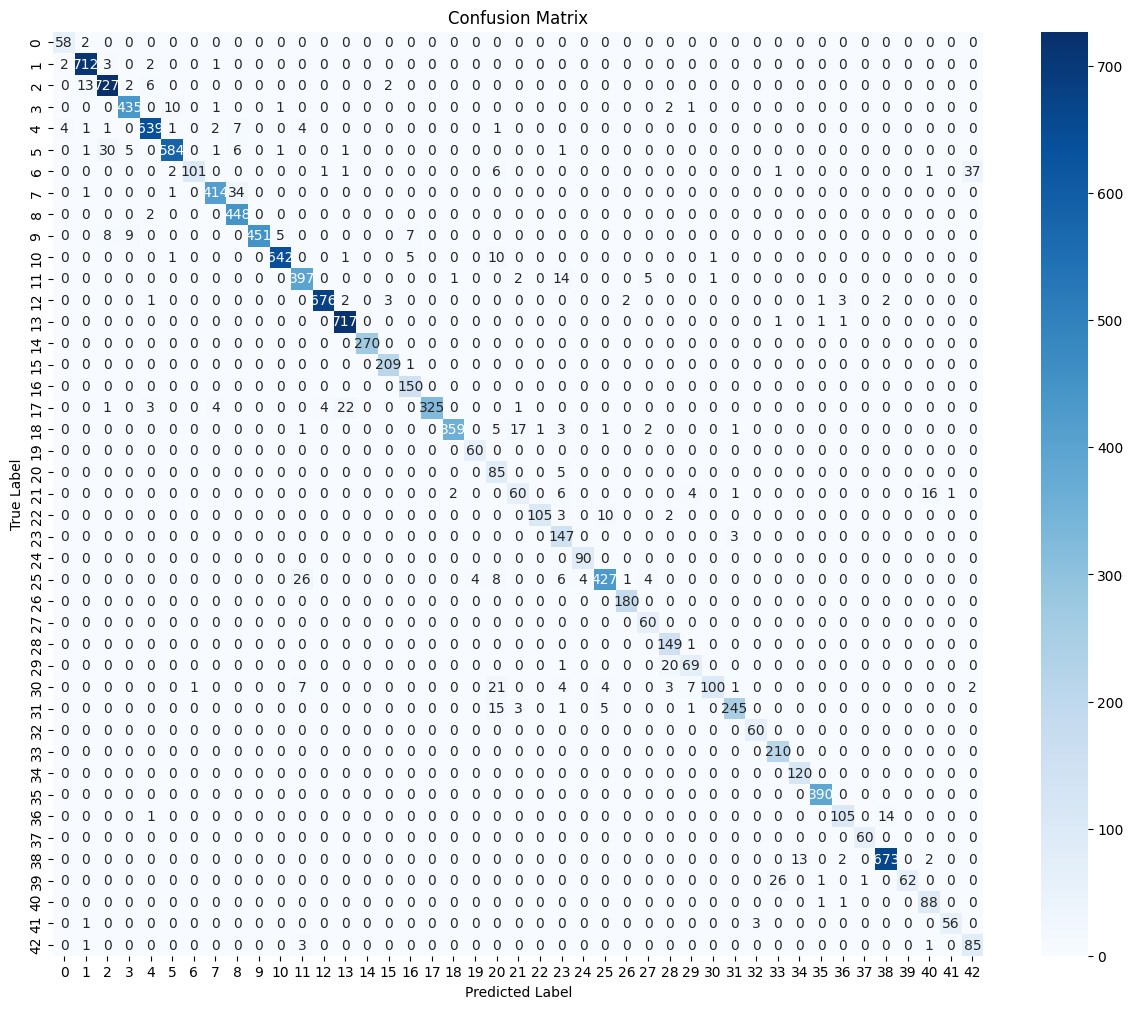

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get the best performing model from the trained_models dictionary (assuming SimpleCNN_WithAug is the target)
model_to_evaluate = trained_models.get('SimpleCNN')

if model_to_evaluate is None:
    print("Error: No model found in 'trained_models' dictionary for evaluation. Please ensure a model is trained and stored.")
else:
    print(f"\n--- Evaluating {model_to_evaluate.name} on Test Data ---")

    # Make predictions on the test set
    y_pred_probs = model_to_evaluate.predict(X_test)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # Convert one-hot encoded y_test_categorical back to class labels for comparison
    y_true_classes = y_test # y_test already contains the original integer labels

    # 1. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes))

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


### **5.1 ResNet vs CNN**

This study compares the performance of a custom CNN model trained without data augmentation with the ResNet50 transfer learning model for traffic sign classification. Both models were evaluated using the same training and testing datasets to ensure a fair comparison. The evaluation focuses on key performance metrics, including training accuracy, validation accuracy, test accuracy, loss values, and computational efficiency. The objective is to determine which model provides better classification performance for the given dataset.


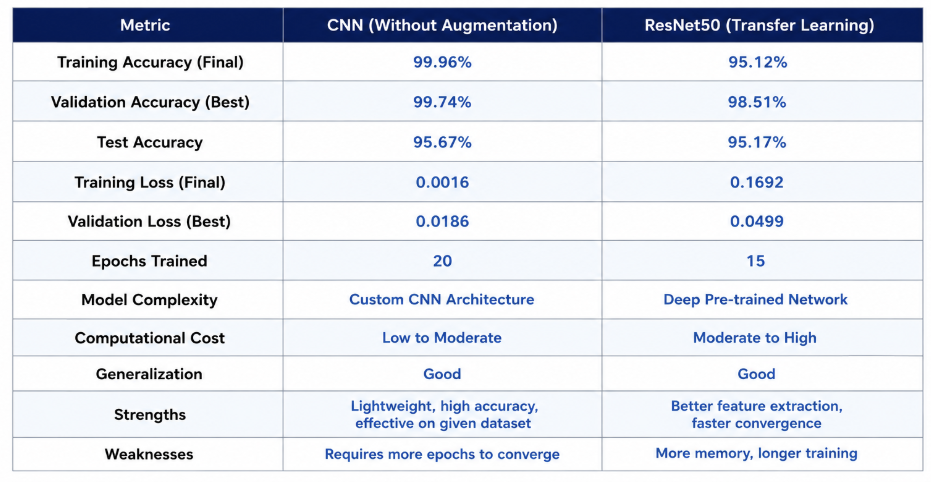

## 5.2 Accuracy Comparison

The CNN model without augmentation achieved a training accuracy of 99.96%, a best validation accuracy of 99.74%, and a test accuracy of 95.67%. In comparison, ResNet50 achieved a training accuracy of 95.12%, a best validation accuracy of 98.51%, and a test accuracy of 95.17%. Furthermore, the CNN model recorded lower training and validation losses (0.0016 and 0.0186) than ResNet50 (0.1692 and 0.0499). These results indicate that the CNN model provided slightly better classification performance on the traffic sign dataset.

| Model    | Test Accuracy |
| -------- | ------------- |
| CNN      | 95.67 %       |
| ResNet50 | 95.17 %       |


## 5.3 Computational Efficiency Comparison

* The CNN model uses a simpler network architecture compared to the deeper ResNet50 model, resulting in lower computational complexity and reduced memory requirements.

* Although the CNN required 20 epochs to achieve its best performance, while ResNet50 converged in 15 epochs, the CNN achieved higher accuracy and lower loss values.

* ResNet50 benefits from transfer learning and faster convergence, but its deeper architecture requires greater computational resources. Therefore, the CNN model offers an effective balance between performance and computational efficiency.


## 6. Challenges Faced

*	Several challenges were encountered during the development and training of the CNN-based traffic sign recognition system.

* One of the major challenges was handling variations in traffic sign appearances caused by differences in illumination, viewing angles, background clutter, and weather conditions.

*	Another challenge was preventing overfitting, as the model exhibited a gap between training and validation performance.

* Fine-tuning hyperparameters such as learning rate, batch size, and dropout rate was necessary to achieve stable convergence and improve the model's generalization capability.



## 7. Key Learnings

   This project provided valuable practical experience in deep learning and computer vision. The major learnings obtained from this work include:

  * Understanding the working principles of Convolutional Neural Networks (CNNs)

  *	Learning image preprocessing techniques such as resizing, normalization, and augmentation.

  * Gaining knowledge about Batch Normalization and Dropout for improving model performance.

  *	Understanding evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrices.

  * Developing skills in hyperparameter tuning and analyzing training and validation curves.

  * Understanding the importance of balancing model complexity and computational efficiency.







##8. Future Scope

The proposed CNN-based traffic sign recognition system can be further enhanced
in several ways:
Increasing the size and diversity of the training dataset to improve
classification performance.

* Applying advanced data augmentation techniques to reduce overfitting.

* Incorporating deeper CNN architectures to extract more discriminative image features.

* Implementing real-time traffic sign detection using object detection models such as YOLO.

* Deploying the trained model on edge devices or mobile platforms for intelligent transportation applications.

* Integrating the system with Advanced Driver Assistance Systems (ADAS) and autonomous vehicles.

## 9. Conclusion

In this project, a Traffic Sign Recognition System was developed using both a custom CNN model and a Transfer Learning model based on ResNet50. The models were trained and evaluated on German and Indian traffic sign datasets to classify multiple traffic sign categories accurately.

Comparative analysis revealed that the CNN model achieved better classification performance, obtaining a test accuracy of 95.67% and demonstrating improved generalization capabilities. The results confirm that transfer learning is an effective approach for traffic sign recognition and can significantly contribute to intelligent transportation systems, advanced driver assistance systems, and autonomous vehicle technologies.


# **10. References**

1.	Andriy Burkov, “The Hundred-Page Machine Learning Book”. ISBN-13: 978-1999579500, Published 2019.

2.	Marc Peter Deisenroth, A. Aldo Faisal and Cheng Soon Ong “Mathematics for Machine Learning Book”. ISBN-13: 978-1108470049, Cambridge University Press, 2020.

3.	Andriy Burkov, “Machine Learning Engineering Book”. Published 2020.

4.	Andreas C. Müller and Sarah Guido, “Introduction to Machine Learning with Python Book”. ISBN: 9781449369897, O’Reilly Published 2016.

5.	Parampreet Kaur, Rajeev Sobti and Aditya Khamparia “Simulation and Deep CNN based architecture for validation of Intelligent automotive functions”, https://ieeexplore.ieee.org/document/8554611.

6.	Kanwar Bharat Singh and Mustafa Ali Arat “Deep Learning in the Automotive Industry: Recent Advances and Application Examples”, https://arxiv.org/abs/1906.08834.

7.	Hongbo Gao, Bo Cheng, Jianqiang Wang, Keqiang Li, Jianhui Zhao, and Deyi Li,  “Object Classification Using CNN-Based Fusion of Vision and LIDAR in Autonomous Vehicle Environment”, https://ieeexplore.ieee.org/document/8331162.  

8.	“Google Colab, A Hosted Jupyter Notebook”, https://colab.research.google.com/.

9.	 “Kaggle, A Data Science Competition Platform and Online Community for Data Scientists and Machine Learning Practitioners under Google LLC ”, https://www.kaggle.com/.

10.	Johannes Stallkamp, Marc Schlipsing, Jan Salmen and Christian Igel, “German Traffic Sign Recognition Benchmark GTSRB”,  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/published-archive.html.

11.	Andre Luckow, Matthew Cook, Nathan Ashcraft, Edwin Weill, Emil Djerekarov, and Bennie Vorster “Deep Learning in the Automotive Industry: Applications and Tools”, https://ieeexplore.ieee.org/document/7841045.

12.	“GTSRB Dataset”, https://benchmark.ini.rub.de/gtsrb_dataset.html.  


14.	Jelena Koci´c, Nenad Joviˇci´c and Vujo Drndarevi´c, “An End-to-End Deep Neural Network for Autonomous Driving Designed for Embedded Automotive Platforms”, https://www.mdpi.com/1424-8220/19/9/2064.

15.	Shihao Yin, Jicai Deng, Dawei Zhang and Jingyuan Du, “Traffic Sign Recognition Based on Deep Convolutional Neural Network”, https://link.springer.com/chapter/10.1007/978-981-10-7299-4_57.

16.	Sumit Saha, “A Guide to Convolutional Neural Networks — the ELI5 way”, https://saturncloud.io/blog/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way/.

17.	J. Stallkamp, M. Schlipsing, J. Salmen, and C. Igel. The German Traffic Sign Recognition Benchmark: A multi-class classification competition. In Proceedings of the IEEE International Joint Conference on Neural Networks, pages 1453–1460. 2011.

18.	Shin Wee Fiona Liou, Hau-Lee Tong, Kok-Why Ng, and Hu Ng. CNN-Based Traffic Sign Recognition. In Proceedings of the International Conference on Computer, Information Technology and Intelligent Computing (CITIC 2022), 10, pp. 195–204, 2022.

19.	Dan Cireşan, Ueli Meier, Juergen Schmidhuber. Multi-column Deep Neural Networks for Image Classification, et al. (2012).



